# Tugas 1 - Klasifikasi Jamur dengan Naive Bayes

| Nama | NRP |
|------|-----|
| Benedictus Ryu Gunawan | 5054251001|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Mushroom Dataset dari UCI Machine Learning Repository.

Dataset dapat diakses melalui:
- https://www.kaggle.com/datasets/uciml/mushroom-classification

Untuk metadata / penjelasan mengenai dataset bisa mengakses link berikut:
- https://archive.ics.uci.edu/dataset/73/mushroom

Tujuan utama dari tugas ini adalah membangun dan membandingkan tiga varian Naive Bayes, yaitu Categorical NB, Bernoulli NB, dan Multinomial NB, untuk mengklasifikasikan apakah suatu jamur dapat dimakan (edible) atau beracun (poisonous).

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan untuk masing-masing varian Naive Bayes.
3. Eksperimen Model
   - Bangun model Categorical NB, Bernoulli NB, dan Multinomial NB.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil ketiga model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [51]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import os
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from dataclasses import dataclass

@dataclass
class Config:
    SEED: int = 42
    ROOT_DIR: Path = Path(os.getcwd())
    DATA_DIR : Path = ROOT_DIR / "data"
    OUTPUT_DIR : Path = ROOT_DIR / "output"

cfg = Config()
cfg.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Root directory: {cfg.ROOT_DIR}")
print(f"Data directory: {cfg.DATA_DIR}")
print(f"Output directory: {cfg.OUTPUT_DIR}")

Root directory: /home/ryz/data/collage/sem 3/ml/Modul-Praktikum-ML-RKA/2.Naive_Bayes,Logistic_Regression
Data directory: /home/ryz/data/collage/sem 3/ml/Modul-Praktikum-ML-RKA/2.Naive_Bayes,Logistic_Regression/data
Output directory: /home/ryz/data/collage/sem 3/ml/Modul-Praktikum-ML-RKA/2.Naive_Bayes,Logistic_Regression/output


In [52]:
# Load dataset dan tampilkan beberapa baris pertama.
# Semua nilai pada dataset berupa single character yang merupakan kode singkatan dari kategori.
# Contoh: pada kolom class, e = edible dan p = poisonous.from sklearn.pro
df = pd.read_csv(cfg.DATA_DIR / "mushrooms.csv", na_values="?")
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [53]:
# Tampilkan informasi dasar dataset: jumlah baris dan kolom, tipe data, dan jumlah missing value.
# Perhatikan kolom stalk-root yang memiliki nilai '?' sebagai representasi missing value.

display(df.info())

print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                5644 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

None

Jumlah baris: 8124
Jumlah kolom: 23


Number of Missing: 2480


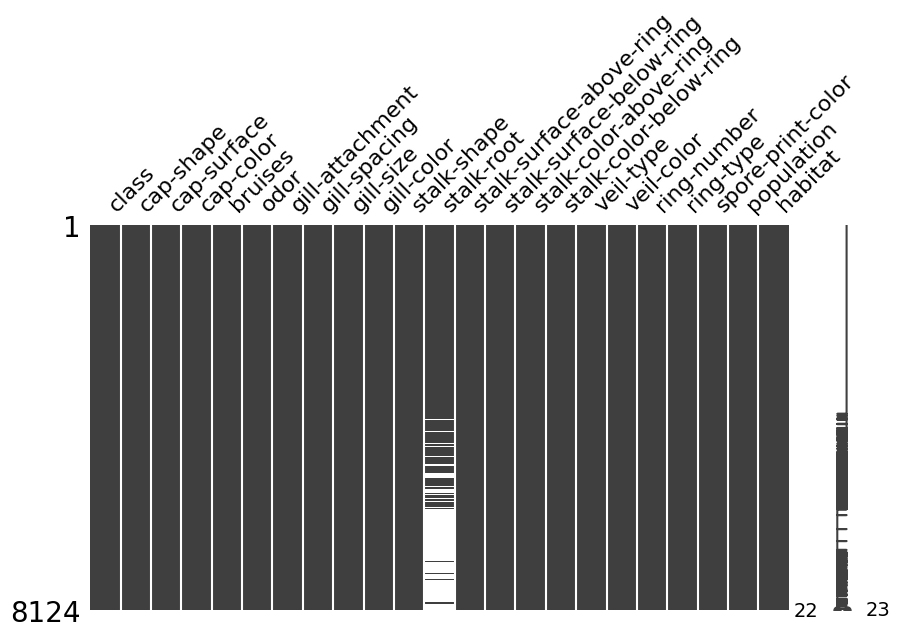

In [54]:
import missingno as msno

msno.matrix(df, figsize=(10, 5))
print(f"Number of Missing: {df.isnull().sum().sum()}")

gill-color                  12
cap-color                   10
odor                         9
stalk-color-below-ring       9
spore-print-color            9
stalk-color-above-ring       9
habitat                      7
cap-shape                    6
population                   6
ring-type                    5
cap-surface                  4
stalk-surface-above-ring     4
veil-color                   4
stalk-surface-below-ring     4
stalk-root                   4
ring-number                  3
gill-attachment              2
class                        2
bruises                      2
gill-size                    2
gill-spacing                 2
stalk-shape                  2
veil-type                    1
dtype: int64


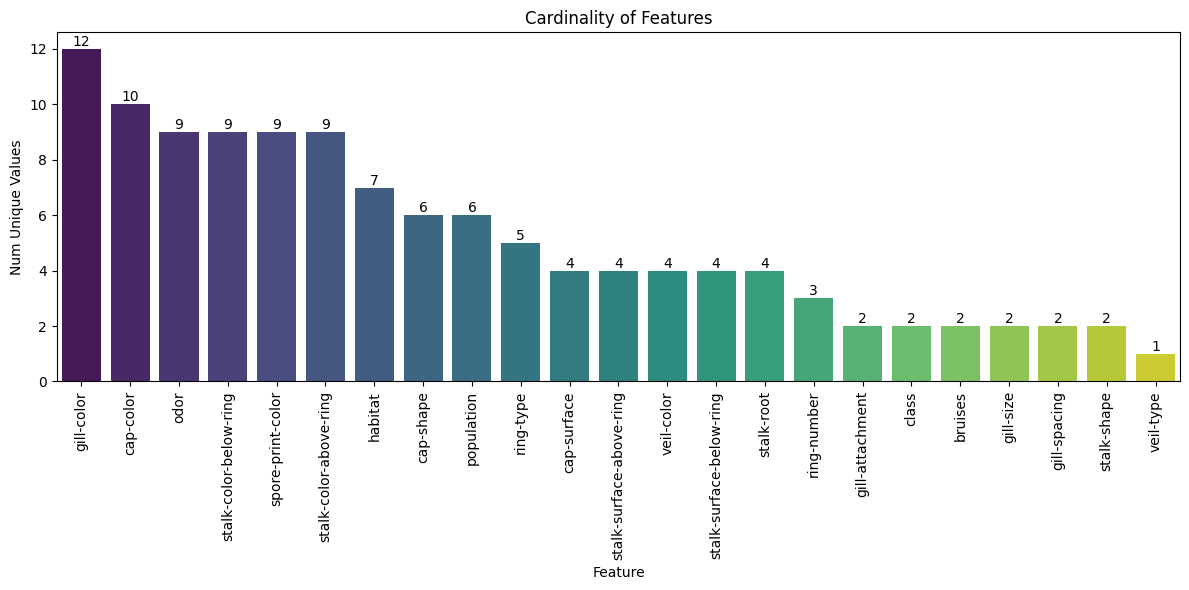

In [55]:
# Tampilkan jumlah nilai unik pada setiap fitur.
# Perhatikan variasi jumlah kategori antar fitur, misalnya veil-type hanya punya 1 nilai unik.
cardinality = df.nunique().sort_values(ascending=False)
print(cardinality)

plt.figure(figsize=(12, 6))
plt.title("Cardinality of Features")
sns.barplot(x=cardinality.index, y=cardinality.values, hue=cardinality.index, palette="viridis", legend=False)
for index, value in enumerate(cardinality.values):
    plt.text(index, value, str(value), ha='center', va='bottom')
plt.xticks(rotation=90)
plt.xlabel("Feature")
plt.ylabel("Num Unique Values")
plt.tight_layout()


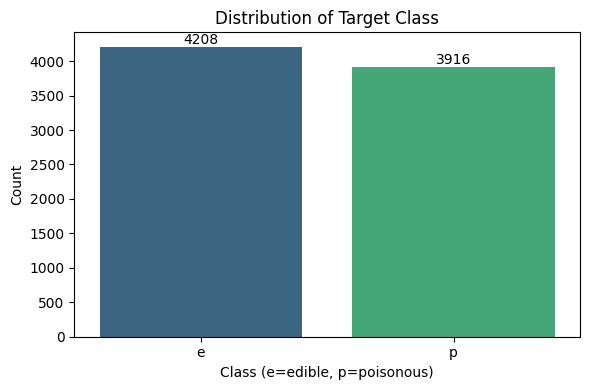

In [56]:
# Tampilkan distribusi kelas target (class) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.

class_counts = df['class'].value_counts()
plt.figure(figsize=(6, 4))
plt.title("Distribution of Target Class")
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette="viridis", legend=False)
for index, value in enumerate(class_counts.values):
    plt.text(index, value, str(value), ha='center', va='bottom')
plt.xlabel("Class (e=edible, p=poisonous)")
plt.ylabel("Count")
plt.tight_layout()


## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

In [57]:
from scipy.stats import chi2_contingency

target = "class"

for col in df.select_dtypes(include=["object"]).columns:
    if col == target:
        continue

    table = pd.crosstab(df[col], df[target])

    chi2, p, dof, exp = chi2_contingency(table)

    print(f"{col:10} chi2={chi2:.2f} p={p:.5f}")


cap-shape  chi2=489.92 p=0.00000
cap-surface chi2=315.04 p=0.00000
cap-color  chi2=387.60 p=0.00000
bruises    chi2=2041.42 p=0.00000
odor       chi2=7659.73 p=0.00000
gill-attachment chi2=133.99 p=0.00000
gill-spacing chi2=984.14 p=0.00000
gill-size  chi2=2366.83 p=0.00000
gill-color chi2=3765.71 p=0.00000
stalk-shape chi2=84.14 p=0.00000
stalk-root chi2=638.26 p=0.00000
stalk-surface-above-ring chi2=2808.29 p=0.00000
stalk-surface-below-ring chi2=2684.47 p=0.00000
stalk-color-above-ring chi2=2237.90 p=0.00000
stalk-color-below-ring chi2=2152.39 p=0.00000
veil-type  chi2=0.00 p=1.00000
veil-color chi2=191.22 p=0.00000
ring-number chi2=374.74 p=0.00000
ring-type  chi2=2956.62 p=0.00000
spore-print-color chi2=4602.03 p=0.00000
population chi2=1929.74 p=0.00000
habitat    chi2=1573.78 p=0.00000


# 2. Preprocessing

Karena semua fitur bertipe kategorikal, setiap varian Naive Bayes membutuhkan representasi data yang berbeda:

| Model | Representasi yang dibutuhkan | Preprocessing |
|---|---|---|
| Categorical NB | Integer per kategori | OrdinalEncoder |
| Bernoulli NB | Binary 0/1 per kategori | LabelBinarizer / OneHotEncoder |
| Multinomial NB | Count / frekuensi non-negatif | OneHotEncoder |

In [58]:
print("Data Duplicated Rows:", df.duplicated().sum())

Data Duplicated Rows: 0


In [59]:
data_version = dict()

## 2.1 Imputasi

In [60]:
# Periksa apakah ada fitur yang hanya memiliki satu nilai unik.
# Fitur seperti itu tidak memberikan informasi apapun dan sebaiknya di-drop.

df = df.drop(columns=[col for col in df.columns if df[col].nunique() == 1])
df

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,s,w,w,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,s,w,w,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,s,w,w,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,s,w,w,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,s,w,w,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,s,o,o,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,s,o,o,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,s,o,o,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,s,k,w,w,w,o,e,w,v,l


In [61]:
# Tangani missing value pada kolom stalk-root (nilai '?').
# Pilih strategi yang sesuai: drop baris, ganti dengan modus, atau jadikan kategori tersendiri.

df_mode = df.copy()
df_mode['stalk-root'] = df_mode['stalk-root'].fillna(df_mode['stalk-root'].mode()[0])

df_drop = df.copy()
df_drop = df_drop.dropna(subset=['stalk-root'])

df_category = df.copy()
df_category['stalk-root'] = df_category['stalk-root'].fillna('?')

data_version['mode'] = df_mode
data_version['drop'] = df_drop
data_version['category'] = df_category

for k, v in data_version.items():
    print(f"{k}: shape={v.shape}, missing={v.isnull().sum().sum()}")


mode: shape=(8124, 22), missing=0
drop: shape=(5644, 22), missing=0
category: shape=(8124, 22), missing=0


In [63]:
# Preprocessing untuk Categorical NB:
# Gunakan OrdinalEncoder untuk mengubah setiap kategori menjadi integer.
# Contoh: cap-shape b=0, c=1, f=2, k=3, s=4, x=5
# Fit hanya pada train set, transform pada train set dan test set.

def preprocess_categorical_nb(df_input):
    from sklearn.preprocessing import OrdinalEncoder

    X = df_input.drop(columns=[target])
    y = df_input[target].map({'e': 0, 'p': 1})

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=cfg.SEED
    )

    encoder = OrdinalEncoder()
    X_train_encoded = encoder.fit_transform(X_train)
    X_test_encoded = encoder.transform(X_test)

    return X_train_encoded, X_test_encoded, y_train, y_test, encoder


In [64]:
# Preprocessing untuk Bernoulli NB dan Multinomial NB:
# Gunakan OneHotEncoder untuk mengubah setiap kategori menjadi representasi binary.
# Hasilnya berupa matriks sparse dengan nilai 0 dan 1.
# Fit hanya pada train set, transform pada train set dan test set.

def preprocess_onehot_nb(df_input):
    from sklearn.preprocessing import OneHotEncoder

    X = df_input.drop(columns=[target])
    y = df_input[target].map({'e': 0, 'p': 1})

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=cfg.SEED
    )

    encoder = OneHotEncoder(handle_unknown='ignore')
    X_train_encoded = encoder.fit_transform(X_train)
    X_test_encoded = encoder.transform(X_test)

    return X_train_encoded, X_test_encoded, y_train, y_test, encoder


# 3. Eksperimen Model

In [ ]:
from sklearn.base import BaseEstimator
from typing import Any

@dataclass
class ModelEvaluation:
    model_name: str
    data_version: str
    model: BaseEstimator
    accuracy: float
    precision: float
    recall: float
    f1_score: float
    y_test: Any = None
    y_pred: Any = None
    y_proba: Any = None

evaluations = []


## 3.1 Categorical Naive Bayes

CategoricalNB adalah varian yang paling sesuai untuk dataset ini karena semua fitur memang bertipe kategorikal. Model menghitung P(fitur=kategori | kelas) secara langsung untuk setiap kategori pada setiap fitur.

Training CategoricalNB with mode strategy for missing values...
Results for mode strategy:
              precision    recall  f1-score   support

      Edible       0.91      0.99      0.95       842
   Poisonous       0.99      0.90      0.94       783

    accuracy                           0.95      1625
   macro avg       0.95      0.95      0.95      1625
weighted avg       0.95      0.95      0.95      1625

Training CategoricalNB with drop strategy for missing values...
Results for drop strategy:
              precision    recall  f1-score   support

      Edible       0.96      1.00      0.98       698
   Poisonous       1.00      0.93      0.96       431

    accuracy                           0.97      1129
   macro avg       0.98      0.96      0.97      1129
weighted avg       0.97      0.97      0.97      1129

Training CategoricalNB with category strategy for missing values...
Results for category strategy:
              precision    recall  f1-score   support

      Edib

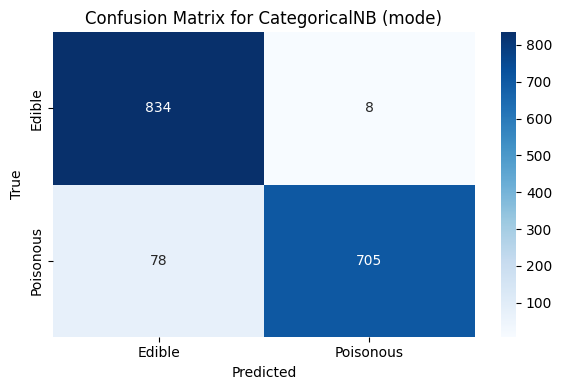

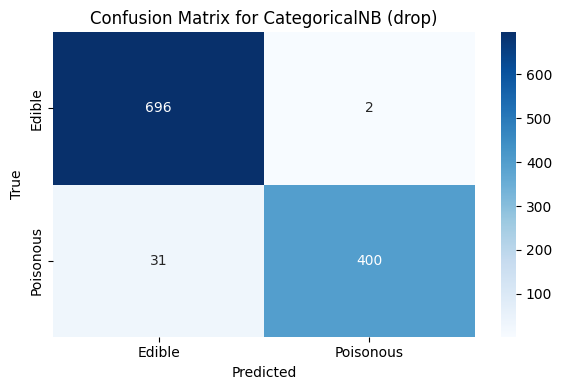

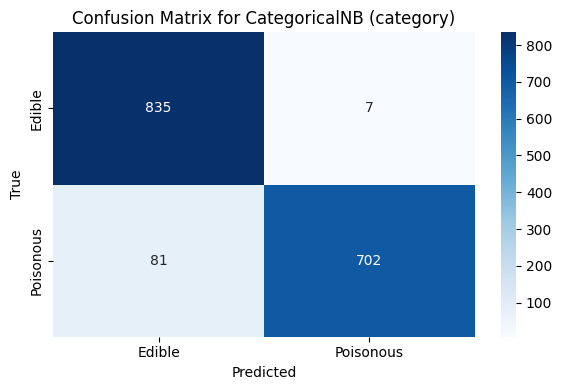

In [66]:
# Inisialisasi dan latih model CategoricalNB menggunakan train set hasil OrdinalEncoder.
from sklearn.naive_bayes import CategoricalNB, BernoulliNB, MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

for version, df_version in data_version.items():
    print(f"Training CategoricalNB with {version} strategy for missing values...")
    X_train_encoded, X_test_encoded, y_train, y_test, encoder = preprocess_categorical_nb(df_version)

    model = CategoricalNB()
    model.fit(X_train_encoded, y_train)

    # Lakukan prediksi pada test set.
    # Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
    y_pred = model.predict(X_test_encoded)
    y_proba = model.predict_proba(X_test_encoded)[:, 1]

    evaluations.append(ModelEvaluation(
        model_name="CategoricalNB",
        data_version=version,
        model=model,
        accuracy=accuracy_score(y_test, y_pred),
        precision=precision_score(y_test, y_pred),
        recall=recall_score(y_test, y_pred),
        f1_score=f1_score(y_test, y_pred),
        y_test=y_test,
        y_pred=y_pred,
        y_proba=y_proba,
    ))

    print(f"Results for {version} strategy:")
    print(classification_report(y_test, y_pred, target_names=['Edible', 'Poisonous']))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Edible', 'Poisonous'], yticklabels=['Edible', 'Poisonous'])
    plt.title(f"Confusion Matrix for CategoricalNB ({version})")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()


## 3.2 Bernoulli Naive Bayes

BernoulliNB bekerja pada representasi binary. Dengan OneHotEncoder, setiap kategori menjadi kolom tersendiri bernilai 0 atau 1, sehingga model memperlakukan setiap kategori sebagai fitur binary ada/tidak ada.

Training BernoulliNB with mode strategy for missing values...
Results for mode strategy:
              precision    recall  f1-score   support

      Edible       0.90      0.99      0.94       842
   Poisonous       0.98      0.88      0.93       783

    accuracy                           0.93      1625
   macro avg       0.94      0.93      0.93      1625
weighted avg       0.94      0.93      0.93      1625

Training BernoulliNB with drop strategy for missing values...
Results for drop strategy:
              precision    recall  f1-score   support

      Edible       0.92      1.00      0.95       698
   Poisonous       0.99      0.85      0.92       431

    accuracy                           0.94      1129
   macro avg       0.95      0.92      0.94      1129
weighted avg       0.95      0.94      0.94      1129

Training BernoulliNB with category strategy for missing values...
Results for category strategy:
              precision    recall  f1-score   support

      Edible    

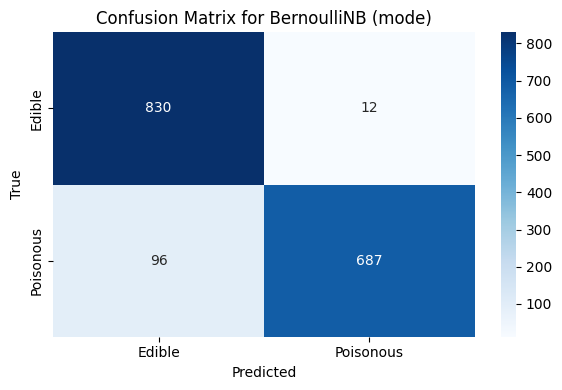

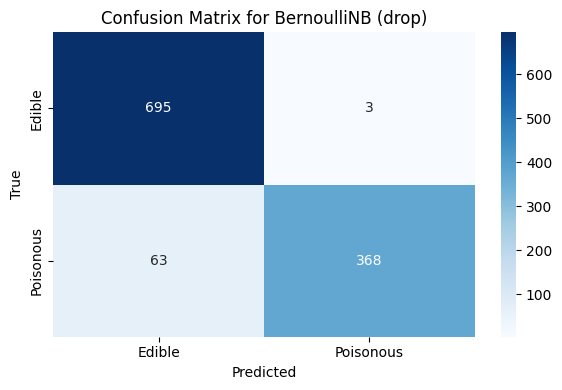

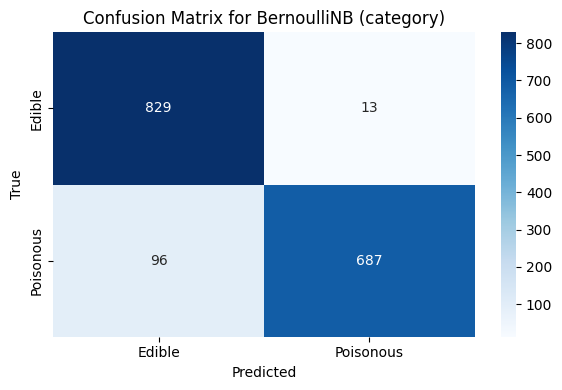

In [67]:
# Inisialisasi dan latih model BernoulliNB menggunakan train set hasil OneHotEncoder.

for version, df_version in data_version.items():
    print(f"Training BernoulliNB with {version} strategy for missing values...")
    X_train_encoded, X_test_encoded, y_train, y_test, encoder = preprocess_onehot_nb(df_version)

    model = BernoulliNB()
    model.fit(X_train_encoded, y_train)

    # Lakukan prediksi pada test set.
    # Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
    y_pred = model.predict(X_test_encoded)
    y_proba = model.predict_proba(X_test_encoded)[:, 1]

    evaluations.append(ModelEvaluation(
        model_name="BernoulliNB",
        data_version=version,
        model=model,
        accuracy=accuracy_score(y_test, y_pred),
        precision=precision_score(y_test, y_pred),
        recall=recall_score(y_test, y_pred),
        f1_score=f1_score(y_test, y_pred),
        y_test=y_test,
        y_pred=y_pred,
        y_proba=y_proba,
    ))

    print(f"Results for {version} strategy:")
    print(classification_report(y_test, y_pred, target_names=['Edible', 'Poisonous']))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Edible', 'Poisonous'], yticklabels=['Edible', 'Poisonous'])
    plt.title(f"Confusion Matrix for BernoulliNB ({version})")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()


## 3.3 Multinomial Naive Bayes

MultinomialNB membutuhkan input non-negatif dan menginterpretasikannya sebagai frekuensi. Dengan OneHotEncoder yang menghasilkan nilai 0 dan 1, model dapat menerimanya sebagai counts meskipun secara semantik tiap nilai hanya menandakan ada/tidak ada kategori.

Training MultinomialNB with mode strategy for missing values...
Results for mode strategy:
              precision    recall  f1-score   support

      Edible       0.91      0.99      0.95       842
   Poisonous       0.99      0.90      0.94       783

    accuracy                           0.95      1625
   macro avg       0.95      0.95      0.95      1625
weighted avg       0.95      0.95      0.95      1625

Training MultinomialNB with drop strategy for missing values...
Results for drop strategy:
              precision    recall  f1-score   support

      Edible       0.96      1.00      0.98       698
   Poisonous       1.00      0.93      0.96       431

    accuracy                           0.97      1129
   macro avg       0.98      0.96      0.97      1129
weighted avg       0.97      0.97      0.97      1129

Training MultinomialNB with category strategy for missing values...
Results for category strategy:
              precision    recall  f1-score   support

      Edib

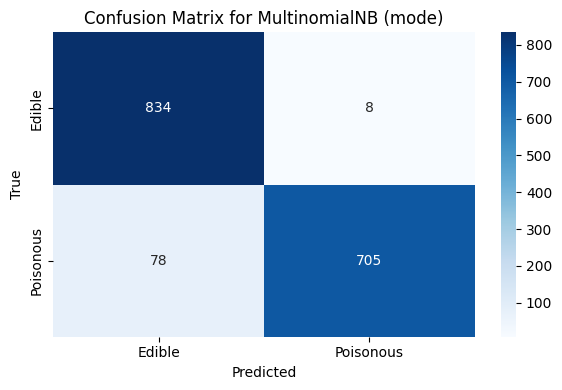

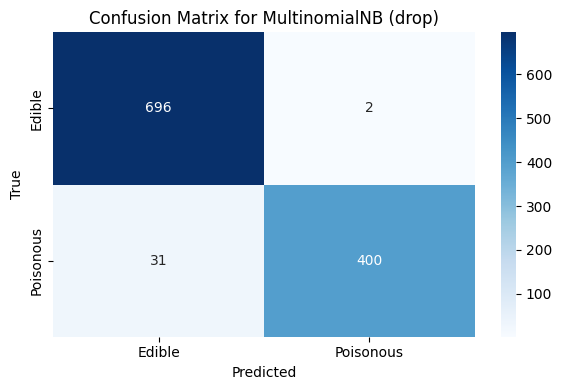

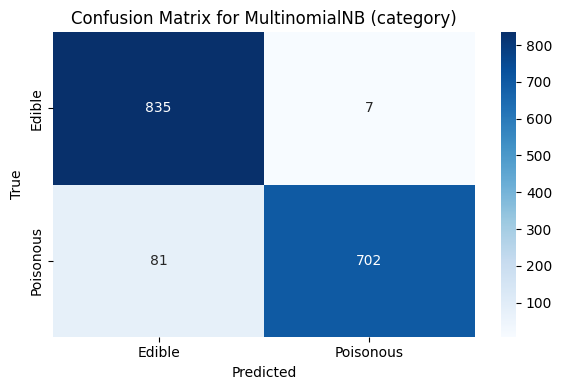

In [68]:
# Inisialisasi dan latih model MultinomialNB menggunakan train set hasil OneHotEncoder.

for version, df_version in data_version.items():
    print(f"Training MultinomialNB with {version} strategy for missing values...")
    X_train_encoded, X_test_encoded, y_train, y_test, encoder = preprocess_onehot_nb(df_version)

    model = MultinomialNB()
    model.fit(X_train_encoded, y_train)

    # Lakukan prediksi pada test set.
    # Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
    y_pred = model.predict(X_test_encoded)
    y_proba = model.predict_proba(X_test_encoded)[:, 1]

    evaluations.append(ModelEvaluation(
        model_name="MultinomialNB",
        data_version=version,
        model=model,
        accuracy=accuracy_score(y_test, y_pred),
        precision=precision_score(y_test, y_pred),
        recall=recall_score(y_test, y_pred),
        f1_score=f1_score(y_test, y_pred),
        y_test=y_test,
        y_pred=y_pred,
        y_proba=y_proba,
    ))

    print(f"Results for {version} strategy:")
    print(classification_report(y_test, y_pred, target_names=['Edible', 'Poisonous']))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Edible', 'Poisonous'], yticklabels=['Edible', 'Poisonous'])
    plt.title(f"Confusion Matrix for MultinomialNB ({version})")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()


# 4. Evaluasi Model

,Model,Imputasi,Accuracy,Precision,Recall,F1
5,BernoulliNB,category,0.9329,0.9814,0.8774,0.9265
4,BernoulliNB,drop,0.9415,0.9919,0.8538,0.9177
3,BernoulliNB,mode,0.9335,0.9828,0.8774,0.9271
2,CategoricalNB,category,0.9458,0.9901,0.8966,0.9410
1,CategoricalNB,drop,0.9708,0.9950,0.9281,0.9604
0,CategoricalNB,mode,0.9471,0.9888,0.9004,0.9425
8,MultinomialNB,category,0.9458,0.9901,0.8966,0.9410
7,MultinomialNB,drop,0.9708,0.9950,0.9281,0.9604
6,MultinomialNB,mode,0.9471,0.9888,0.9004,0.9425


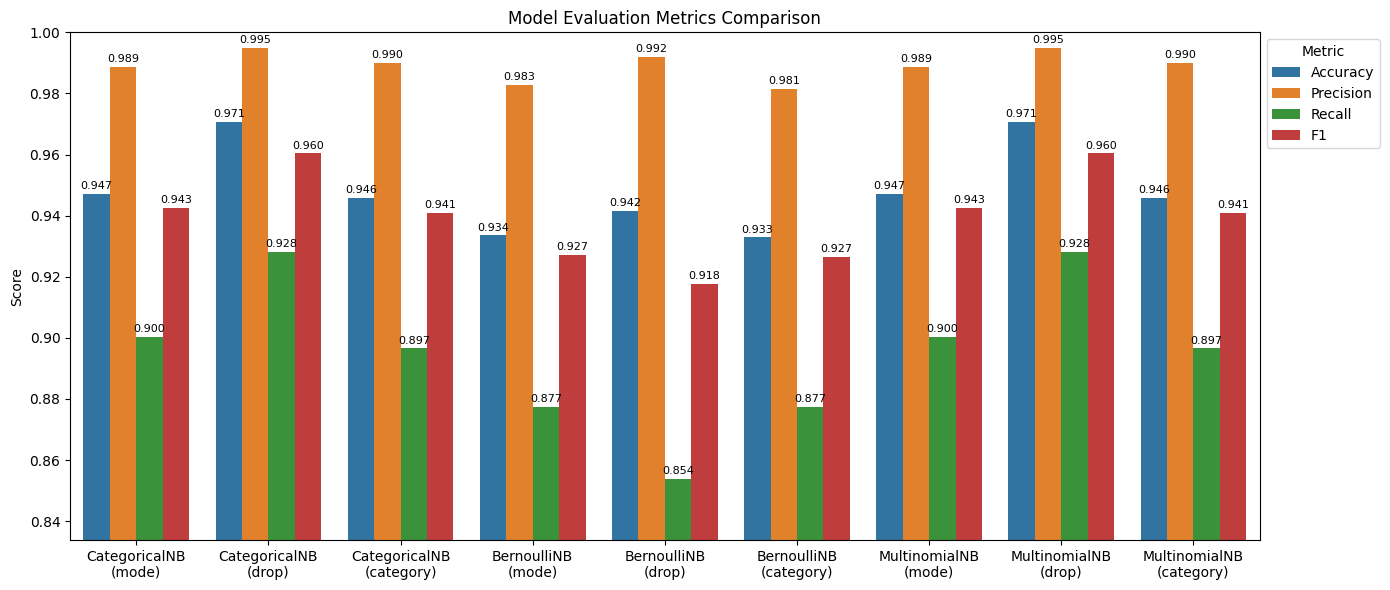

In [85]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
# Tabel hasil
results_df = pd.DataFrame([
    {
        "Model": e.model_name,
        "Imputasi": e.data_version,
        "Accuracy": e.accuracy,
        "Precision": e.precision,
        "Recall": e.recall,
        "F1": e.f1_score,
    }
    for e in evaluations
])

display(
    results_df.sort_values(["Model", "Imputasi"])
    .style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}"
    })
)

# Long format untuk plotting
plot_df = results_df.melt(
    id_vars=["Model", "Imputasi"],
    value_vars=["Accuracy", "Precision", "Recall", "F1"],
    var_name="Metric",
    value_name="Score"
)

plot_df["Label"] = (
    plot_df["Model"] +
    "\n(" + plot_df["Imputasi"] + ")"
)

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=plot_df,
    x="Label",
    y="Score",
    hue="Metric"
)

ax.set_title("Model Evaluation Metrics Comparison")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.set_ylim(
    plot_df["Score"].min() - 0.02,
    min(1.0, plot_df["Score"].max() + 0.02)
)

# Label nilai di atas setiap bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        fontsize=8,
        rotation=0,
        padding=2
    )

plt.xticks(rotation=0)
plt.legend(title="Metric", loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

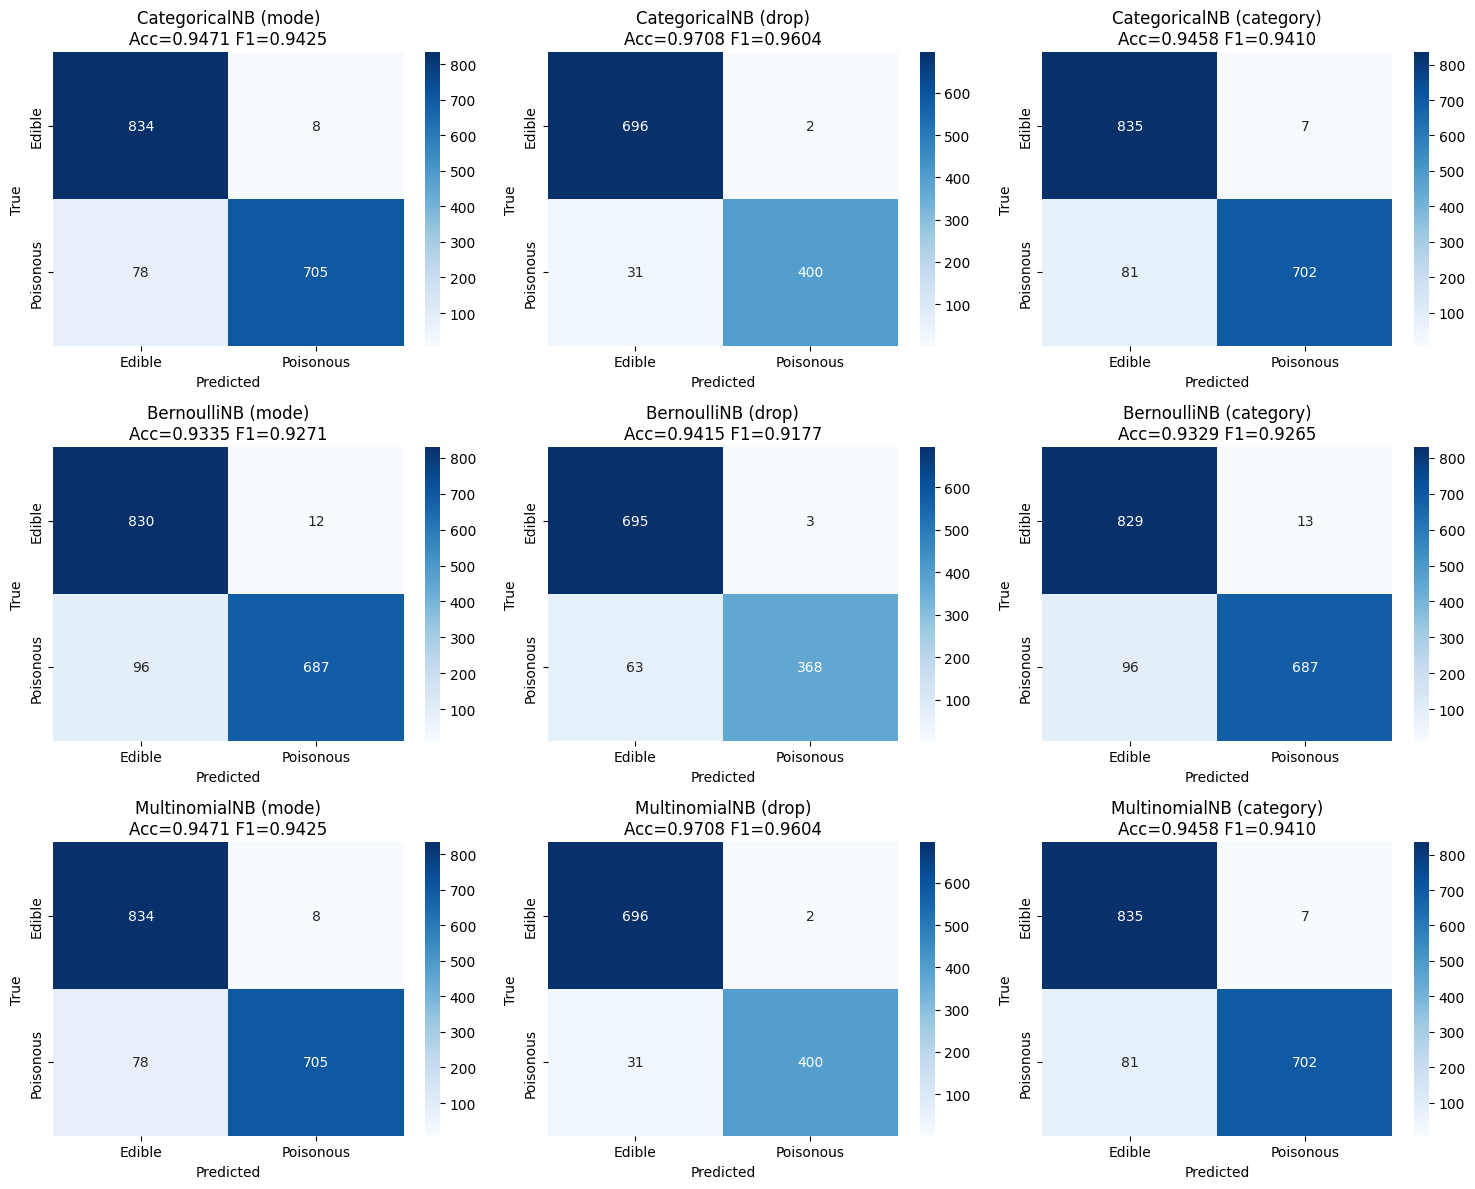

In [70]:
import math

n_cols = len(data_version)  # 3 strategi imputasi
n_rows = math.ceil(len(evaluations) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(n_rows, n_cols)

for i, e in enumerate(evaluations):
    r, c = divmod(i, n_cols)
    cm = confusion_matrix(e.y_test, e.y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Edible', 'Poisonous'],
                yticklabels=['Edible', 'Poisonous'], ax=axes[r, c])
    axes[r, c].set_title(f"{e.model_name} ({e.data_version})\nAcc={e.accuracy:.4f} F1={e.f1_score:.4f}")
    axes[r, c].set_xlabel("Predicted")
    axes[r, c].set_ylabel("True")

plt.tight_layout()


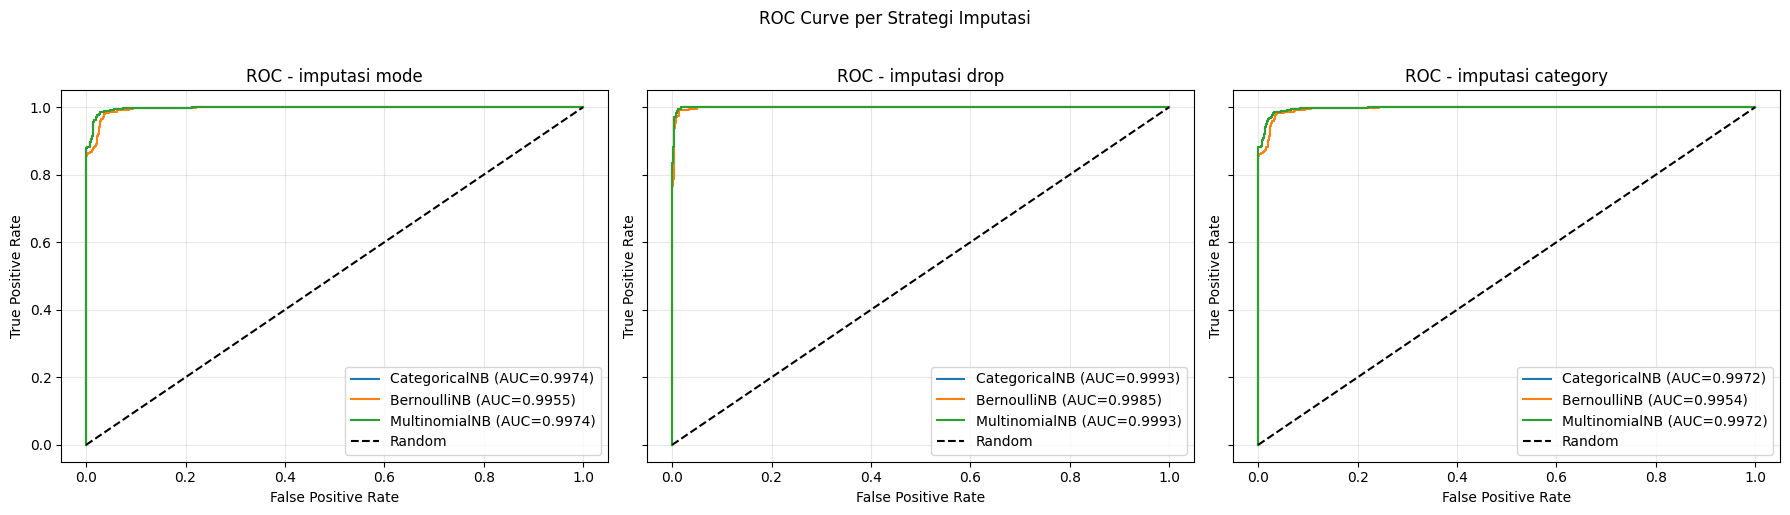

In [71]:
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(1, len(data_version), figsize=(6 * len(data_version), 5), sharey=True)
if len(data_version) == 1:
    axes = [axes]

for ax, version in zip(np.atleast_1d(axes), list(data_version.keys())):
    for e in [ev for ev in evaluations if ev.data_version == version]:
        fpr, tpr, _ = roc_curve(e.y_test, e.y_proba)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{e.model_name} (AUC={roc_auc:.4f})")
    ax.plot([0, 1], [0, 1], 'k--', label='Random')
    ax.set_title(f"ROC - imputasi {version}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)

plt.suptitle("ROC Curve per Strategi Imputasi", y=1.02)
plt.tight_layout()


# 5. Analisis

#### 5.1 Ringkasan hasil eksperimen

Hasil 9 kombinasi (3 model × 3 strategi imputasi `stalk-root`) dari eksekusi notebook ini:

| Model | Imputasi | Akurasi | Precision | Recall | F1 | AUC | Test (n) |
|---|---|---|---|---|---|---|---|
| CategoricalNB | mode | 0.9471 | 0.9888 | 0.9004 | 0.9425 | 0.9974 | 1625 |
| BernoulliNB | mode | 0.9335 | 0.9828 | 0.8774 | 0.9271 | 0.9955 | 1625 |
| MultinomialNB | mode | 0.9471 | 0.9888 | 0.9004 | 0.9425 | 0.9974 | 1625 |
| CategoricalNB | drop | 0.9708 | 0.9950 | 0.9281 | 0.9604 | 0.9993 | 1129 |
| BernoulliNB | drop | 0.9415 | 0.9919 | 0.8538 | 0.9177 | 0.9985 | 1129 |
| MultinomialNB | drop | 0.9708 | 0.9950 | 0.9281 | 0.9604 | 0.9993 | 1129 |
| CategoricalNB | category | 0.9458 | 0.9901 | 0.8966 | 0.9410 | 0.9972 | 1625 |
| BernoulliNB | category | 0.9329 | 0.9814 | 0.8774 | 0.9265 | 0.9954 | 1625 |
| MultinomialNB | category | 0.9458 | 0.9901 | 0.8966 | 0.9410 | 0.9972 | 1625 |

Kelas positif = 1 = poisonous. Precision = proporsi prediksi poisonous yang benar-benar beracun; Recall = proporsi jamur beracun yang berhasil ditangkap.

Confusion matrix (TN=edible benar, FP=edible dikira beracun, FN=beracun dikira edible, TP=beracun benar):

| Model (mode) | TN | FP | FN | TP |
|---|---|---|---|---|
| CategoricalNB | 834 | 8 | 78 | 705 |
| BernoulliNB | 830 | 12 | 96 | 687 |
| MultinomialNB | 834 | 8 | 78 | 705 |

Pola yang sama pada versi `drop` (mis. Categorical: 696/2/31/400) dan `category` (835/7/81/702 vs Bernoulli 829/13/96/687).

#### 5.2 Perbandingan tiga varian Naive Bayes

**1. CategoricalNB ≈ MultinomialNB (identik di semua versi).**
Ini hasil yang diharapkan, bukan kebetulan. CategoricalNB memakai `OrdinalEncoder` (satu integer per fitur, 21 kolom) dan memodelkan $P(fitur_j=kategori|kelas)$ secara langsung. MultinomialNB memakai `OneHotEncoder` (~115 kolom biner) dan memodelkannya sebagai count 0/1. Karena setiap sampel tepat memiliki **satu** kolom aktif per fitur asal (satu one-hot group berjumlah 1), likelihood Multinomial tereduksi menjadi perkalian peluang kategori yang sama dengan CategoricalNB (dengan smoothing `alpha=1.0` yang sama). Maka prediksi, akurasi, dan AUC-nya sama persis (mis. mode: 0.9471 / AUC 0.9974).

**2. BernoulliNB konsisten paling rendah (~1–3 poin di bawah).**
Selisih terbesar ada di **recall**: mode 0.8774 vs 0.9004; drop 0.8538 vs 0.9281 (selisih 7.4 poin, FN 63 vs 31). Penyebabnya adalah representasi data: `OneHotEncoder` satu fitur asal dipecah menjadi banyak kolom biner yang **saling eksklusif** (jika `cap-shape=x` aktif, maka `cap-shape=b/c/f/...` pasti 0). BernoulliNB menganggap tiap kolom biner sebagai kejadian independen dan secara eksplisit memodelkan $P(x_i=0|kelas)$ juga, sehingga asumsi independensi dilanggar lebih parah dibanding dua varian lain. Akibatnya model lebih sering gagal mengenali jamur beracun (FN tinggi). AUC-nya tetap tinggi (0.995–0.998) artinya ranking probabilitasnya bagus, tetapi threshold 0.5 menghasilkan keputusan yang lebih buruk.

**3. Error didominasi False Negative, bukan False Positive.**
Di semua model FP hanya 2–13, sedangkan FN 31–96. Precision (~0.98–0.995) jauh lebih tinggi dari recall (~0.85–0.93). Artinya: kalau model bilang "beracun", hampir pasti benar; masalahnya adalah jamur beracun yang lolos dikira "edible". Ini sisi berbahaya untuk aplikasi nyata

#### 5.3 Pengaruh strategi imputasi `stalk-root`

Missing value (`?` → NaN) sebanyak 2480 baris (30.5%) dan **tidak acak (MNAR)**: 70.9% baris yang missing adalah poisonous, vs hanya 38.2% pada baris non-missing. Dampaknya:

- **`mode` vs `category` hampir sama** (0.9471 vs 0.9458). Mengisi dengan modus maupun menjadikannya kategori `'?'` tidak mengubah banyak karena `stalk-root` bukan fitur terkuat (chi2=638, jauh di bawah `odor`=7659).
- **`drop` terlihat terbaik (0.9708) tetapi tidak sebanding.** Dengan membuang 30.5% data, test set berubah (1129 vs 1625) dan distribusinya bergeser (61.8% edible vs 51.8% pada mode) karena baris beracun yang banyak missing ikut terbuang. Model dievaluasi pada subset yang lebih mudah dan kecil, jadi angkanya naik semu dengan harga kehilangan data besar.
- Untuk perbandingan model yang fair, acuan yang benar adalah versi `mode`/`category` (test set identik, n=1625).

#### 5.4 Kaitan dengan EDA

- `veil-type` hanya 1 nilai unik (chi2=0.00, p=1.0) sehingga tepat di-drop: tidak ada informasi.
- `odor` adalah fitur terkuat (chi2≈7659): nilai `a`/`l` murni edible, `c/f/m/p/s/y` murni/hampir murni poisonous. Ini menjelaskan mengapa semua model mudah mencapai akurasi >0.93.
- Semua fitur lain juga signifikan (p≈0.00000), jadi wajar Naive Bayes yang mengandalkan sinyal kategorikal bekerja sangat baik di dataset ini.


# 6. Kesimpulan dan Saran

#### 6.1 Kesimpulan

1. **CategoricalNB adalah varian paling tepat untuk dataset ini** (akurasi 0.9471, F1 0.9425, AUC 0.9974 pada imputasi modus), setara dengan MultinomialNB. Keduanya sesuai dengan sifat data kategorikal murni (21 fitur hasil `OrdinalEncoder` vs ~115 kolom biner hasil `OneHotEncoder`).
2. **BernoulliNB paling lemah** (akurasi 0.9335, recall hanya 0.8774) karena asumsi independensi antar kolom biner dilanggar oleh kolom-kolom one-hot yang saling eksklusif dalam satu fitur asal.
3. **Imputasi modus direkomendasikan**: tanpa kehilangan data dan performa setara kategori `'?'` (0.9471 vs 0.9458). Strategi `drop` memang mencetak angka tertinggi (0.9708) tetapi menyesatkan karena membuang 30.5% data yang justru didominasi kelas poisonous sehingga test set-nya tidak sebanding.
4. **Risiko utama adalah False Negative** (jamur beracun diprediksi edible, 78 kasus pada model terbaik) dengan recall poisonous ~0.90. Untuk konteks keamanan pangan, recall lebih penting daripada akurasi.

#### 6.2 Saran

1. **Tuning dan validasi lebih ketat**: grid search `alpha` (smoothing) tiap varian + stratified k-fold cross-validation agar perbandingan tidak bergantung pada satu split 80:20.
2. **Cost-sensitive / threshold tuning**: geser threshold probabilitas atau beri bobot kelas agar recall poisonous naik (mis. dari kurva ROC yang AUC-nya sudah ~0.997, ada ruang menaikkan recall dengan sedikit mengorbankan precision), karena FN jauh lebih berbahaya daripada FP.
3. **Ablasi fitur**: uji model tanpa `odor` untuk mengukur ketergantungan pada satu fitur dominan, serta cek interaksi fitur yang melanggar asumsi Naive Bayes.
4. **Perlakuan missing yang informatif**: karena missing `stalk-root` berkorelasi dengan kelas beracun, pertimbangkan mempertahankannya sebagai fitur/kategori eksplisit (`category`) daripada dibuang, atau modelkan mekanismenya.
5. **Pembanding non-Naive Bayes**: coba Decision Tree / Random Forest / Logistic Regression di atas one-hot untuk melihat apakah asumsi independensi memang bottleneck, serta laporkan interval kepercayaan metriknya.
